# Fixed theoretical c on CartPole

FHR-DQN (`agents/sb3_fhr.FHRDQN`, a stable_baselines3 DQN subclass — λ=0 is bit-exact stock DQN) where the order-2 recurrence constants are **fixed at their theoretical z-domain values** instead of learned, compared against learned-c arms at the same λ and against the stock baseline. Every arm also runs the penalised-window rank probe, so the spectrum is measured on exactly the replay windows the penalty acts on.

**The theory.** Along a trajectory $Q_t = r_t + \gamma Q_{t+1}$. CartPole's reward is constant ($r \equiv 1$), so the value signal has exactly two poles: $z = 1$ (constant-reward mode) and $z = 1/\gamma$ (discount mode). The order-2 annihilator is the product of the two first-order factors

$$(1 - z^{-1})(1 - \gamma^{-1} z^{-1}) = 1 - \underbrace{(1 + 1/\gamma)}_{c_1}\, z^{-1} + \underbrace{(1/\gamma)}_{-c_2}\, z^{-2}$$

so $Q_t = c_1 Q_{t-1} + c_2 Q_{t-2}$ with, at $\gamma = 0.99$:

$$c_1 = 1 + \tfrac{1}{\gamma} = 2.0101\ldots \qquad c_2 = -\tfrac{1}{\gamma} = -1.0101\ldots$$

Checks: $c_1 + c_2 = 1$ (constant sequences are fixed points) and the companion roots are exactly $\{1, 1/\gamma\}$ — the theoretical recurrence is marginally *expansive* (radius $1/\gamma > 1$). These are the Bellman init of `FHRRecurrenceHead`, so the fixed arms are simply `c_learning_rate: 0.0`: the coefficient param group's Adam update is identically zero and the head never leaves its init.

Arms derive from `configs/config_sb3_fhrdwn_fixed.yaml` + the manifest; nothing is hardcoded here.

## 0 · Launch — train whatever the config defines

In [6]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parent / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner
import yaml

CONFIG = "configs/config_sb3_fhrdwn_fixed.yaml"
# Every arm below — launched and analysed — is exactly what the config's
# experiment.fhr_experiments block currently defines; nothing is hardcoded.
EXPERIMENTS = sorted(int(k) for k in
                     (yaml.safe_load(open(CONFIG))["experiment"]
                      .get("fhr_experiments") or {}))
print("config experiments:", EXPERIMENTS)

LAUNCH = True
FORCE_EXP = False
if LAUNCH:
    manifest = runner.launch_all(config=CONFIG, experiments=EXPERIMENTS,
                                 max_workers=4, force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False — analysing existing runs only")

config experiments: [1, 2, 3, 4]
skipping 10 already-completed run(s) recorded in cached/sb3_runs_manifest_fhrdwn_fixed.json
['baseline', 'exp1', 'exp2', 'exp3', 'exp4']


In [7]:
import csv, json
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parents[2]
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
CFG = yaml.safe_load(open(CONFIG))
CMAN = json.load(open("cached/sb3_runs_manifest_fhrdwn_fixed.json"))
SEEDS = [str(s) for s in (CFG["experiment"].get("seeds")
                          or [CFG["experiment"]["seed"]])]
GAMMA = float(CFG["algo"]["gamma"])
C1_THEORY, C2_THEORY = 1.0 + 1.0 / GAMMA, -1.0 / GAMMA
print(f"theoretical constants (gamma = {GAMMA}):  "
      f"c1 = 1 + 1/gamma = {C1_THEORY:.8f}   c2 = -1/gamma = {C2_THEORY:.8f}")

# ---- arms are DERIVED from the config, never hardcoded -------------------
PALETTE = ["tab:red", "tab:blue", "tab:orange", "tab:cyan", "tab:purple",
           "tab:green", "peru", "orchid", "crimson", "tab:olive"]
KIND_ORDER = {"baseline": 0, "fixed": 1, "learned": 2}

def _spec(n, ov):
    lam = float(ov.get("fhr_weight", CFG["agent"]["fhr_weight"]))
    fixed = float(ov.get("c_learning_rate",
                         CFG["agent"]["c_learning_rate"])) == 0.0
    kind = "fixed" if fixed else "learned"
    name = "FIXED theoretical c" if fixed else "learned c"
    return {"arm": f"exp{n}", "kind": kind, "lam": lam,
            "label": f"{name} · λ{lam:g}"}

specs = [{"arm": "baseline", "kind": "baseline", "lam": 0.0,
          "label": "baseline (stock DQN)"}]
unrun = []
for n, ov in sorted((int(k), v) for k, v in
                    (CFG["experiment"].get("fhr_experiments") or {}).items()):
    s = _spec(n, ov)
    (specs if CMAN["runs"].get(s["arm"]) else unrun).append(s)
specs.sort(key=lambda s: (KIND_ORDER[s["kind"]], -s["lam"]))
if unrun:
    print("defined but not yet run:", [s["arm"] for s in unrun])

ARMS, INFO = {}, {}
for i, s in enumerate(specs):
    label = s["label"]
    if label in ARMS:
        label = f"{label} [{s['arm']}]"
    s["colour"] = "black" if s["kind"] == "baseline" else \
                  PALETTE[(i - 1) % len(PALETTE)]
    ARMS[label] = (s["arm"], s["colour"])
    INFO[label] = s

def labels_of(*kinds):
    return [l for l in ARMS if INFO[l]["kind"] in kinds]

BASE = next(iter(labels_of("baseline")), None)
FIXED = labels_of("fixed")
LEARNED = labels_of("learned")

def run_dirs(arm):
    out = []
    for s in SEEDS:
        rel = CMAN["runs"].get(arm, {}).get(s)
        if rel and (pathlib.Path(rel) / "rewards.csv").exists():
            out.append((s, pathlib.Path(rel)))
    return out

def curves(arm, fname="eval.csv", x="env_steps", y="mean_reward"):
    cs = []
    for s, d in run_dirs(arm):
        if not (d / fname).exists():
            continue
        rows = list(csv.DictReader(open(d / fname)))
        if rows:
            cs.append((s, np.array([float(r[x]) for r in rows]),
                       np.array([float(r[y]) for r in rows])))
    return cs

def diag(arm, col):
    return curves(arm, fname="train_diagnostics.csv", x="episode", y=col)

print({l: ARMS[l][0] for l in ARMS})

theoretical constants (gamma = 0.99):  c1 = 1 + 1/gamma = 2.01010101   c2 = -1/gamma = -1.01010101
{'baseline (stock DQN)': 'baseline', 'FIXED theoretical c · λ10': 'exp1', 'FIXED theoretical c · λ1': 'exp4', 'learned c · λ10': 'exp2', 'learned c · λ1': 'exp3'}


## 1 · Learning curves — the main result

One panel per λ, each showing the fixed-theoretical-c arm against its learned-c comparator, with the stock baseline in gray behind both. If theory is all the penalty needs, fixed and learned should track each other; a gap says the optimiser finds constants that work better (or worse) than the Bellman annihilator.

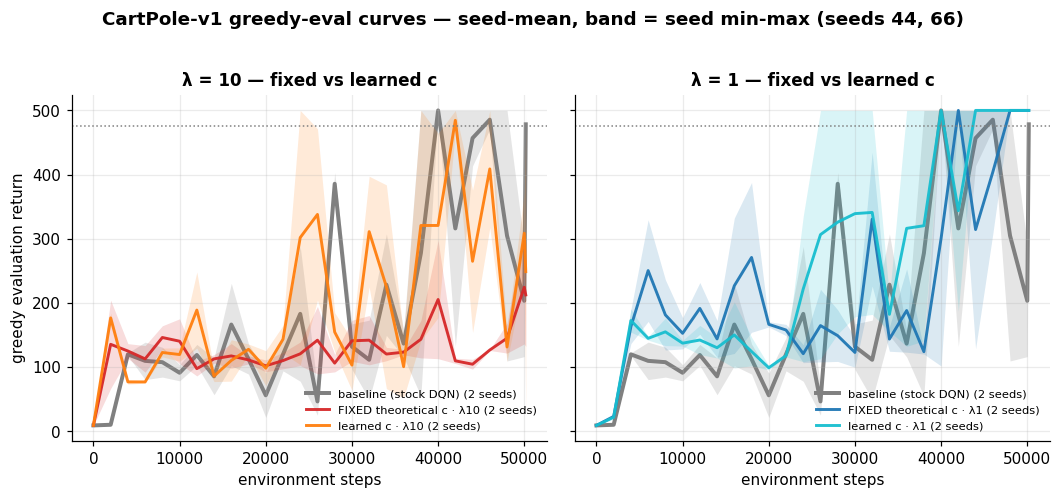

In [8]:
_lams = sorted({INFO[l]["lam"] for l in FIXED + LEARNED}, reverse=True)
GROUPS = [(f"λ = {lam:g} — fixed vs learned c",
           [l for l in FIXED + LEARNED if INFO[l]["lam"] == lam])
          for lam in _lams]
GROUPS = [(t, ls) for t, ls in GROUPS if ls]

def seed_band(ax, label, colr=None, lw=1.9, alpha=0.95, band_alpha=0.16,
              legend=True, zorder=2, **kw):
    cs = curves(ARMS[label][0], **kw)
    if not cs:
        return
    n = min(len(y) for _, _, y in cs)
    x, Y = cs[0][1][:n], np.stack([y[:n] for _, _, y in cs])
    colr = colr or ARMS[label][1]
    if len(cs) > 1:
        ax.fill_between(x, Y.min(0), Y.max(0), color=colr, alpha=band_alpha,
                        lw=0, zorder=zorder - 1)
    ax.plot(x, Y.mean(0), lw=lw, color=colr, alpha=alpha, zorder=zorder,
            label=f"{label} ({len(cs)} seeds)" if legend else None)

fig, axes = plt.subplots(1, max(len(GROUPS), 1),
                         figsize=(4.9 * max(len(GROUPS), 1), 4.4),
                         sharey=True, squeeze=False)
for ax, (title, labels) in zip(axes.ravel(), GROUPS):
    if BASE:
        seed_band(ax, BASE, "gray", lw=2.6, alpha=1.0, band_alpha=0.20,
                  zorder=1)
    for label in labels:
        seed_band(ax, label)
    ax.axhline(CFG["training"]["solved_reward"], color="gray", ls=":", lw=1)
    ax.set(title=title, xlabel="environment steps")
    ax.legend(fontsize=7.5, loc="lower right")
axes[0, 0].set_ylabel("greedy evaluation return")
fig.suptitle(f"{CFG['environment']['name']} greedy-eval curves — seed-mean, "
             f"band = seed min-max (seeds {', '.join(SEEDS)})",
             fontweight="bold", y=1.02)
plt.tight_layout()

## 2 · Final performance

baseline (stock DQN)                   478.4   [456.7, 500.0]
FIXED theoretical c · λ10              212.6   [132.3, 292.9]
FIXED theoretical c · λ1               500.0   [500.0, 500.0]
learned c · λ10                        248.8   [27.2, 470.5]
learned c · λ1                         500.0   [500.0, 500.0]


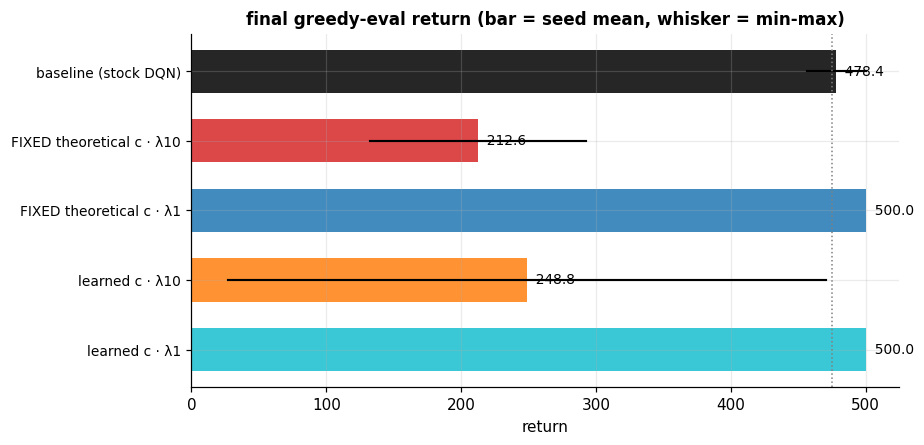

In [9]:
# Final greedy-eval performance per arm (last eval.csv row, mean over seeds)
rows = []
for label in ARMS:
    cs = curves(ARMS[label][0])
    if cs:
        finals = [y[-1] for _, _, y in cs]
        rows.append((label, np.mean(finals), np.min(finals), np.max(finals),
                     ARMS[label][1]))
fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(rows) + 1.4))
ypos = np.arange(len(rows))[::-1]
for y, (label, mean, lo, hi, colr) in zip(ypos, rows):
    ax.barh(y, mean, color=colr, alpha=0.85, height=0.62)
    ax.plot([lo, hi], [y, y], color="black", lw=1.4)
    ax.text(mean, y, f"  {mean:.1f}", va="center", fontsize=9)
ax.axvline(CFG["training"]["solved_reward"], color="gray", ls=":", lw=1)
ax.set_yticks(ypos, [r[0] for r in rows], fontsize=9)
ax.set(title="final greedy-eval return (bar = seed mean, whisker = min-max)",
       xlabel="return")
plt.tight_layout()
for label, mean, lo, hi, _ in rows:
    print(f"{label:34s} {mean:9.1f}   [{lo:.1f}, {hi:.1f}]")

## 3 · FHR internals — do the fixed arms hold the theory, where do the learned arms go?

Per gradient-burst diagnostics, **one row per λ** so each panel carries only the fixed/learned pair it compares. Dotted gray lines mark the theoretical values: $c_1 = 1 + 1/\gamma$, $c_2 = -1/\gamma$, companion radius $1/\gamma$. The fixed arms must sit *exactly* on them for the whole run (asserted below — any drift is a bug); the learned arms show where optimisation takes the constants. A learned drift of the companion radius toward $\le 1$ (dashed line) means the penalty prefers a stabler, contractive recurrence over Bellman's marginally expansive one.

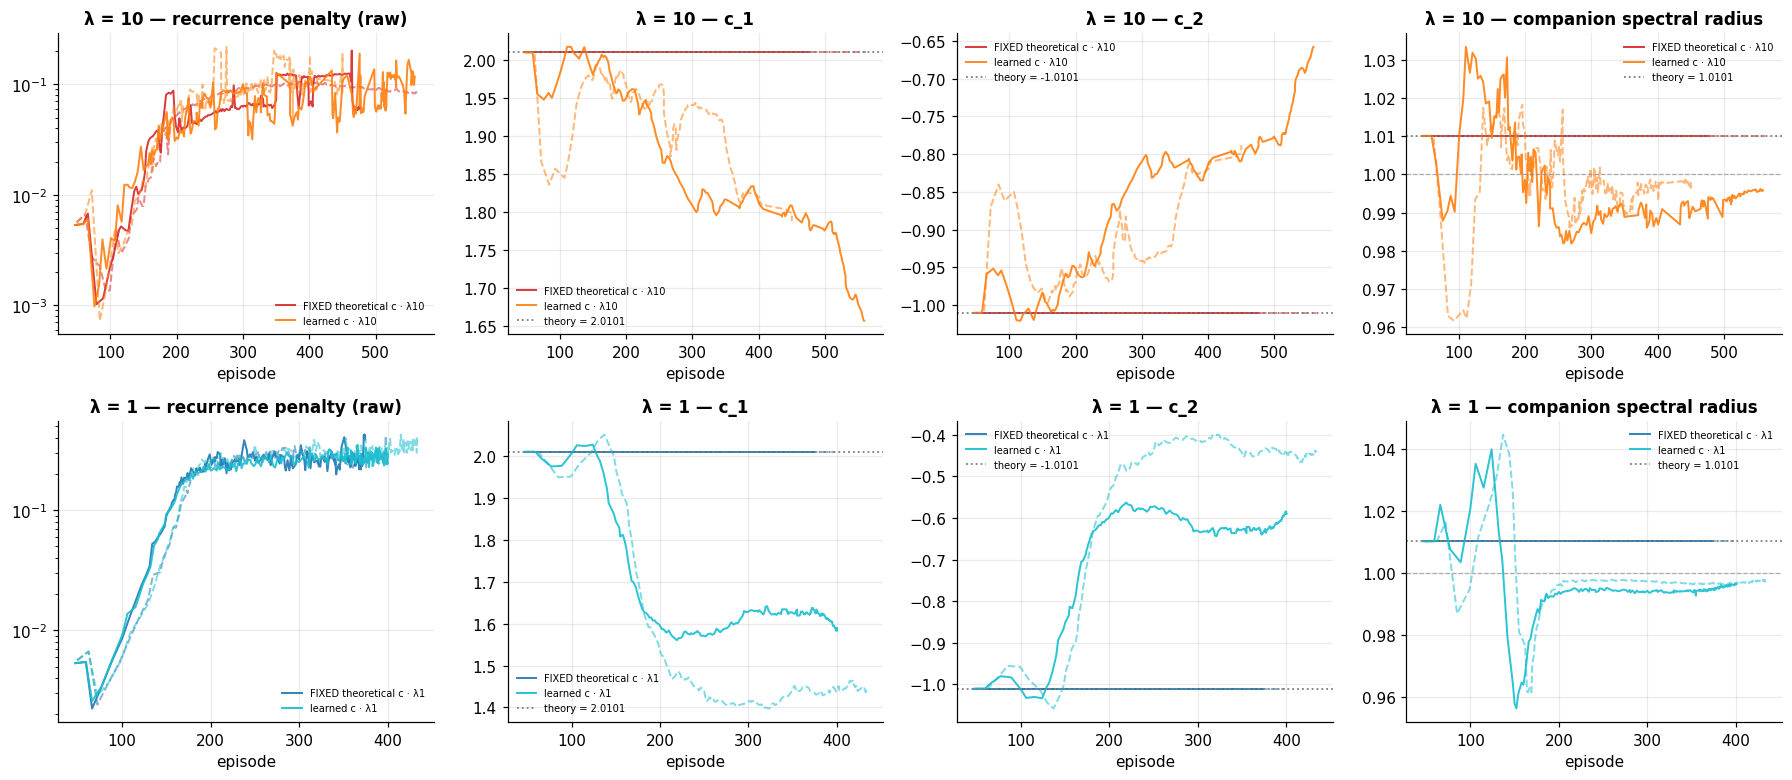

In [10]:
# FHR internals per gradient-burst row, one row per lambda:
# solid = first seed, dashed = second.
LAMS = sorted({INFO[l]["lam"] for l in FIXED + LEARNED}, reverse=True)
panel_defs = [("penalty_raw", "recurrence penalty (raw)", None, True),
              ("c_1", "c_1", C1_THEORY, False),
              ("c_2", "c_2", C2_THEORY, False),
              ("companion_radius", "companion spectral radius",
               1.0 / GAMMA, False)]
fig, axes = plt.subplots(len(LAMS), len(panel_defs),
                         figsize=(4.1 * len(panel_defs), 3.6 * len(LAMS)),
                         squeeze=False)
for row, lam in enumerate(LAMS):
    labels = [l for l in FIXED + LEARNED if INFO[l]["lam"] == lam]
    for ax, (col, title, ref, logy) in zip(axes[row], panel_defs):
        for label in labels:
            for s, x, y in diag(ARMS[label][0], col):
                m = np.isfinite(y)
                if m.any():
                    ax.plot(x[m], y[m], lw=1.3, color=ARMS[label][1],
                            alpha=0.9 if s == SEEDS[0] else 0.55,
                            ls="-" if s == SEEDS[0] else "--",
                            label=label if s == SEEDS[0] else None)
        if ref is not None:
            ax.axhline(ref, color="gray", ls=":", lw=1.2,
                       label=f"theory = {ref:.4f}")
        if col == "companion_radius":
            ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.6)
        ax.set(title=f"λ = {lam:g} — {title}", xlabel="episode")
        if logy:
            ax.set_yscale("log")
        ax.legend(fontsize=6.5)
plt.tight_layout()

FIXED theoretical c · λ10          seed 44: max |c - theory| = 1.01e-06  OK
FIXED theoretical c · λ10          seed 66: max |c - theory| = 1.01e-06  OK
FIXED theoretical c · λ1           seed 44: max |c - theory| = 1.01e-06  OK
FIXED theoretical c · λ1           seed 66: max |c - theory| = 1.01e-06  OK


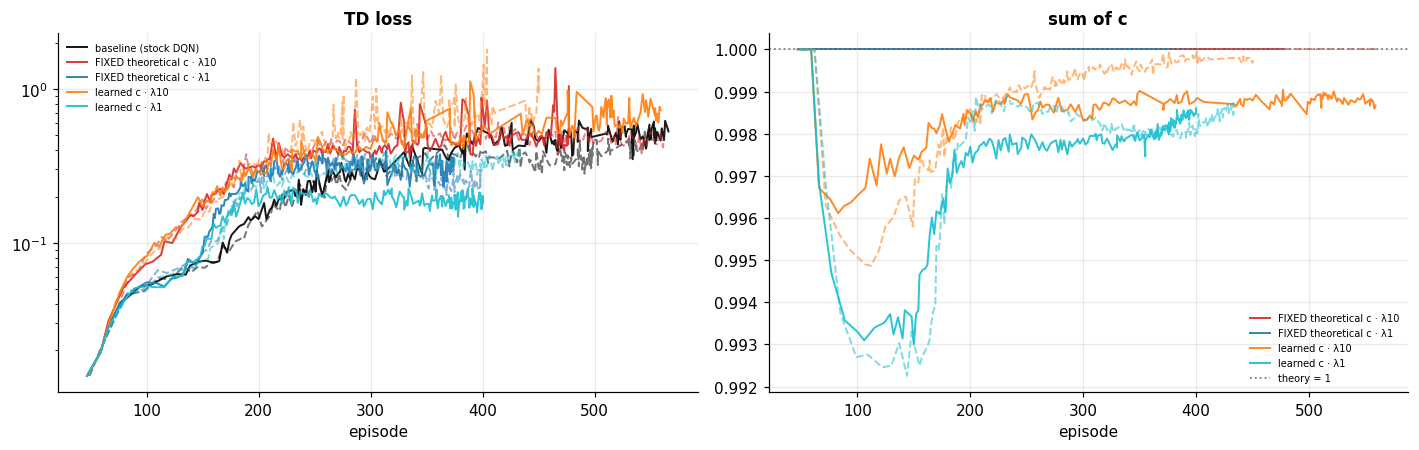

In [11]:
# Shared health panels across every arm: TD loss (baseline included) and
# sum of c (the theory check c1 + c2 = 1).
fig, (ax_td, ax_sc) = plt.subplots(1, 2, figsize=(13, 4.2))
for label in ARMS:
    for s, x, y in diag(ARMS[label][0], "td_loss"):
        m = np.isfinite(y)
        if m.any():
            ax_td.semilogy(x[m], y[m], lw=1.3, color=ARMS[label][1],
                           alpha=0.9 if s == SEEDS[0] else 0.55,
                           ls="-" if s == SEEDS[0] else "--",
                           label=label if s == SEEDS[0] else None)
for label in FIXED + LEARNED:
    for s, x, y in diag(ARMS[label][0], "sum_c"):
        m = np.isfinite(y)
        if m.any():
            ax_sc.plot(x[m], y[m], lw=1.3, color=ARMS[label][1],
                       alpha=0.9 if s == SEEDS[0] else 0.55,
                       ls="-" if s == SEEDS[0] else "--",
                       label=label if s == SEEDS[0] else None)
ax_sc.axhline(1.0, color="gray", ls=":", lw=1.2, label="theory = 1")
ax_td.set(title="TD loss", xlabel="episode")
ax_sc.set(title="sum of c", xlabel="episode")
for ax in (ax_td, ax_sc):
    ax.legend(fontsize=6.5)
plt.tight_layout()

# the fixed arms' constants must never leave the theoretical init
# (tolerance = the diagnostics CSV's ~4-decimal rounding; the learned arms
# drift by ~0.4, three orders of magnitude beyond it)
for label in FIXED:
    arm = ARMS[label][0]
    c2_by_seed = {s: y for s, _, y in diag(arm, "c_2")}
    for s, _, c1s in diag(arm, "c_1"):
        drift = max(np.abs(c1s - C1_THEORY).max(),
                    np.abs(c2_by_seed[s] - C2_THEORY).max())
        assert drift < 1e-4, f"{label} seed {s} drifted off the theory init"
        print(f"{label:34s} seed {s}: max |c - theory| = {drift:.2e}  OK")

## 4 · Penalised-window Hankel rank (in-training probe)

Rank measured **where the penalty is applied** — on sampled replay windows (anchor + `window_rank_lags` same-episode predecessors, online Q-net, buffer actions) rather than on greedy on-policy rollouts. The probe runs for every arm **including the λ=0 baseline**, which samples and measures the same windows, so its curve is the control. The question this family asks: does the **theoretical** annihilator compress the penalised windows as well as the learned one? Windows need 16 same-episode predecessors, so early short episodes yield few windows — the curves fill in as episodes lengthen. Raw window matrices are in each run's `window_matrices/` for offline re-analysis.

arm                                rank@99.9%  rank@99%    s2/s1  pen tail   (final-quarter means, seeds pooled)
baseline (stock DQN)                      1.5       1.0   0.0359    0.0052
FIXED theoretical c · λ10                 1.1       1.0   0.0245    0.0015
FIXED theoretical c · λ1                  1.8       1.0   0.0385    0.0024
learned c · λ10                           1.0       1.0   0.0176    0.0013
learned c · λ1                            1.8       1.0   0.0394    0.0032


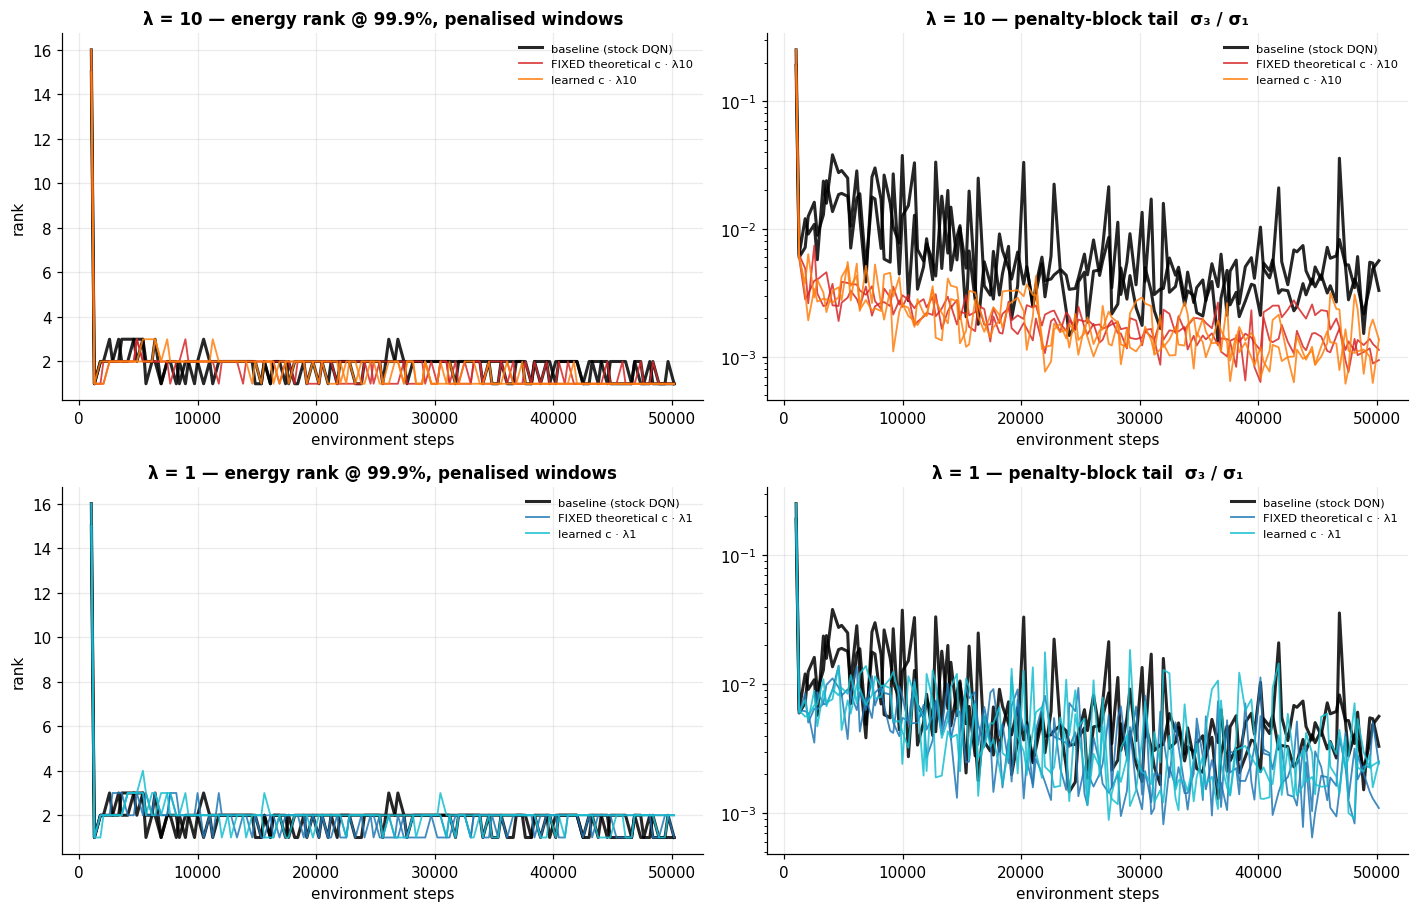

In [12]:
from analysis.low_rank.window_rank import (arm_tick_metrics,
                                           final_quarter_summary)

# One row per lambda: the fixed/learned pair against the shared baseline
# control (bold black), so each panel carries three arms at most.
metrics = {label: arm_tick_metrics(run_dirs(ARMS[label][0]))
           for label in ARMS}
fig, axes = plt.subplots(len(LAMS), 2, figsize=(13, 4.2 * len(LAMS)),
                         squeeze=False)
for row, lam in enumerate(LAMS):
    ax_r, ax_p = axes[row]
    labels = ([BASE] if BASE else []) + \
             [l for l in FIXED + LEARNED if INFO[l]["lam"] == lam]
    for label in labels:
        arm, colr = ARMS[label]
        for k, (seed, m) in enumerate(metrics[label]):
            lw = 2.0 if arm == "baseline" else 1.2
            ax_r.plot(m["env_steps"], m["rank999"], color=colr, alpha=0.85,
                      lw=lw, label=label if k == 0 else None)
            ax_p.semilogy(m["env_steps"], m["pen_tail_ratio"], color=colr,
                          alpha=0.85, lw=lw, label=label if k == 0 else None)
    ax_r.set(title=f"λ = {lam:g} — energy rank @ 99.9%, penalised windows",
             xlabel="environment steps", ylabel="rank")
    ax_p.set(title=f"λ = {lam:g} — penalty-block tail  σ₃ / σ₁",
             xlabel="environment steps")
    for ax in (ax_r, ax_p):
        ax.legend(fontsize=7.5)
plt.tight_layout()

print(f"{'arm':34s} {'rank@99.9%':>10} {'rank@99%':>9} {'s2/s1':>8} "
      f"{'pen tail':>9}   (final-quarter means, seeds pooled)")
for label in ARMS:
    if not metrics[label]:
        print(f"{label:34s} — not instrumented")
        continue
    s = final_quarter_summary(metrics[label])
    if s:
        print(f"{label:34s} {s['rank999']:10.1f} {s['rank99']:9.1f} "
              f"{s['s2_s1']:8.4f} {s['pen_tail_ratio']:9.4f}")

## 5 · Findings

*(fill in after the sweep completes)*